# P1 · Assemble attention tensors

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.11 · Assemble attention tensors

Attention scores compare queries and keys; a causal mask removes future positions before softmax mixes values.

**Prerequisites:** Modules, parameters, and model state

**Predict:** Changing a future value can affect an earlier causal query.

**Mental model:** A query needs a mixture of value vectors from permitted positions. Attention constructs the mixture weights from comparisons between queries and keys.

### Why this operation exists

A query needs a mixture of value vectors from permitted positions. Attention constructs the mixture weights from comparisons between queries and keys.

Each head performs these comparisons with its own feature vectors. Batch and head axes organize independent score matrices.

A causal model must not read future positions while predicting the next character. A mask marks those positions before probabilities are normalized.

Softmax converts permitted scores into nonnegative shares that sum to one over keys. Multiplying by values then forms a weighted mixture.

The calculation is useful to read before deriving every formula. The maths collection supplies the dot-product, scaling and softmax derivations.

### Follow the values

This example has one batch, two illustrative identical heads, three positions and two features per head. Inspect the first head's three query vectors.

Multiply queries by transposed keys and divide by the square root of the feature width. Each score now names one query-position and key-position pair.

The lower-triangular permission matrix allows the current position and its predecessors. Future positions are forbidden.

Replace forbidden scores with negative infinity before softmax. Their shares become zero, and every valid query's remaining shares sum to one.

Mix value vectors using those shares. Change only the final value vector in the experiment: earlier query outputs remain unchanged because their share for that future position is zero.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
q = torch.tensor([[1.,0.],[0.,1.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
k = q.clone()
v = torch.tensor([[2.,0.],[0.,2.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
if change:
    v[:,:,2,:] += 10
show("Queries [B,H,T,Dh]", q)
scores = q @ k.transpose(-2,-1) / math.sqrt(2)
show("Scaled scores, first head", scores[0,0])
allowed = torch.ones(3,3,dtype=torch.bool).tril()
masked = scores.masked_fill(~allowed, float("-inf"))
show("Causal permissions", allowed)
shares = masked.softmax(dim=-1)
show("Shares over key positions", shares[0,0])
mixed = shares @ v
show("Mixtures, first head", mixed[0,0])
assert torch.equal(shares[0,0].triu(1), torch.zeros(3,3))

Queries [B,H,T,Dh]: [[[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]], [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]]
  shape [1, 2, 3, 2] · torch.float32 · cpu
Scaled scores, first head: [[0.7071067690849304, 0.0, 0.7071067690849304], [0.0, 0.7071067690849304, 0.7071067690849304], [0.7071067690849304, 0.7071067690849304, 1.4142135381698608]]
  shape [3, 3] · torch.float32 · cpu
Causal permissions: [[true, false, false], [true, true, false], [true, true, true]]
  shape [3, 3] · torch.bool · cpu
Shares over key positions: [[1.0, 0.0, 0.0], [0.3302384614944458, 0.6697615385055542, 0.0], [0.24825508892536163, 0.24825508892536163, 0.5034898519515991]]
  shape [3, 3] · torch.float32 · cpu
Mixtures, first head: [[2.0, 0.0], [0.6604769229888916, 1.3395230770111084], [1.0, 1.0]]
  shape [3, 2] · torch.float32 · cpu


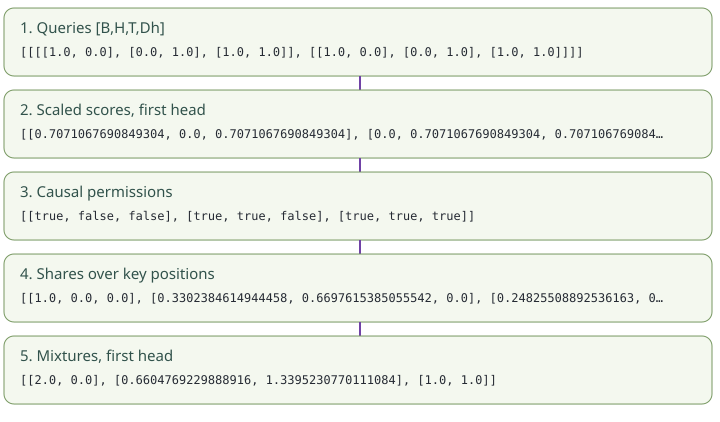

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

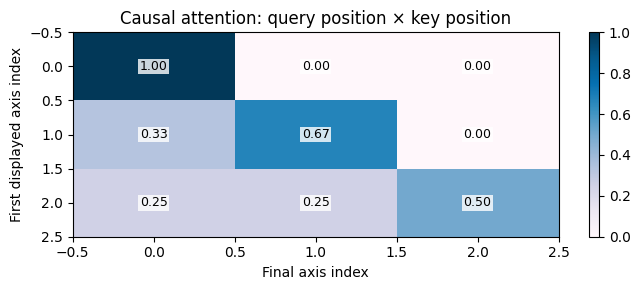

In [5]:
image = (shares[0,0]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Causal attention: query position × key position'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

The final two axes of query and key meet through a batched matrix product. Transpose only the key's feature and time axes.

Construct a Boolean triangular permission matrix. Negating that matrix identifies the entries masked fill must replace.

Softmax uses the final key-position axis. Normalizing across batches or query positions would express a different operation.

Multiply the shares by value vectors, then restore time before heads and merge the head-feature axes. Preserve coordinate meaning at every reshape.

Every query needs at least one allowed key. An entirely masked score vector has no valid probability distribution and produces invalid softmax results.

### Change one thing

**Change only the last value vector**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
q = torch.tensor([[1.,0.],[0.,1.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
k = q.clone()
v = torch.tensor([[2.,0.],[0.,2.],[1.,1.]]).reshape(1,1,3,2).repeat(1,2,1,1)
if change:
    v[:,:,2,:] += 10
show("Queries [B,H,T,Dh]", q)
scores = q @ k.transpose(-2,-1) / math.sqrt(2)
show("Scaled scores, first head", scores[0,0])
allowed = torch.ones(3,3,dtype=torch.bool).tril()
masked = scores.masked_fill(~allowed, float("-inf"))
show("Causal permissions", allowed)
shares = masked.softmax(dim=-1)
show("Shares over key positions", shares[0,0])
mixed = shares @ v
show("Mixtures, first head", mixed[0,0])
assert torch.equal(shares[0,0].triu(1), torch.zeros(3,3))

Queries [B,H,T,Dh]: [[[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]], [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]]
  shape [1, 2, 3, 2] · torch.float32 · cpu
Scaled scores, first head: [[0.7071067690849304, 0.0, 0.7071067690849304], [0.0, 0.7071067690849304, 0.7071067690849304], [0.7071067690849304, 0.7071067690849304, 1.4142135381698608]]
  shape [3, 3] · torch.float32 · cpu
Causal permissions: [[true, false, false], [true, true, false], [true, true, true]]
  shape [3, 3] · torch.bool · cpu
Shares over key positions: [[1.0, 0.0, 0.0], [0.3302384614944458, 0.6697615385055542, 0.0], [0.24825508892536163, 0.24825508892536163, 0.5034898519515991]]
  shape [3, 3] · torch.float32 · cpu
Mixtures, first head: [[2.0, 0.0], [0.6604769229888916, 1.3395230770111084], [6.034898281097412, 6.034898281097412]]
  shape [3, 2] · torch.float32 · cpu


### A useful distinction

Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.

In [7]:
B,T,H,Dh = 2,3,2,2
fused = torch.arange(B*T*3*H*Dh).reshape(B,T,3*H*Dh)
separate = [a.reshape(B,T,H,Dh).transpose(1,2) for a in fused.split(H*Dh,dim=-1)]
five_axes = fused.reshape(B,T,3,H,Dh).permute(2,0,3,1,4)
assert all(torch.equal(a,b) for a,b in zip(separate,five_axes))
assert torch.isnan(torch.tensor([-float("inf"),-float("inf")]).softmax(-1)).all()
print("Five-axis QKV layout matches the separate tensors; entirely masked rows are invalid.")

Five-axis QKV layout matches the separate tensors; entirely masked rows are invalid.


### ✋ Your turn

Create a 3-by-3 Boolean causal permission matrix; put the number of allowed entries in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 6, 'Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = torch.ones(3,3,dtype=torch.bool).tril().sum().item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 6, 'Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.'
    print("✓ right:", answer)

✓ right: 6


### Reconnect to the transformer

The current model projects twenty-eight features into query, key and value groups. Two heads each use fourteen features, and their outputs rejoin into twenty-eight.

Its causal mask is shared across batches and heads. The available time window selects the relevant upper-left portion of the configured mask.

Phyll temporarily reshapes the fused projection into batch, time, three projections, heads and head features, then permutes the projection selector first.

That five-dimensional intermediate organizes the same three tensors; it is not an extra attention mechanism. The notebook verifies the split and fused layouts agree.

Next, follow the other branch in a transformer block: a per-token feed-forward calculation with normalization and a residual addition.

```python
att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
att = F.softmax(att, dim=-1)
y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Changing a future value can affect an earlier causal query.

<details><summary>Check your explanation</summary>

False; its attention share is zero. Mask scores before softmax. Multiplying probabilities by zero afterward generally destroys their normalization.

</details>